In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install joblib

In [ ]:
import os
import re
import json
import joblib
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [ ]:
RANDOM_STATE = 42

EXPERIMENT_NAME = "tfidf_linearsvc_tfidf_lexicon_only_v1"

BASE_DIR = "/content/drive/MyDrive/CS114/TeamModel"
DATA_DIR = os.path.join(BASE_DIR, "data")

TRAIN_PATH = os.path.join(DATA_DIR, "train_clean_tokenizedEmoji.csv")
VAL_PATH = os.path.join(DATA_DIR, "val_clean_tokenizedEmoji.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_clean_tokenizedEmoji.csv")

ARTIFACT_ROOT = os.path.join(BASE_DIR, "experiments", EXPERIMENT_NAME)
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
REPORT_DIR = os.path.join(ARTIFACT_ROOT, "reports")
FIGURE_DIR = os.path.join(ARTIFACT_ROOT, "figures")

for d in [ARTIFACT_ROOT, CHECKPOINT_DIR, REPORT_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

DROP_CROSS_SPLIT_DUPLICATES = True

FEATURE_K = 35000

WORD_NGRAM_RANGE = (1, 3)
CHAR_ANALYZER = "char_wb"
CHAR_NGRAM_RANGE = (3, 5)

WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 30000
WORD_MIN_DF = 3
CHAR_MIN_DF = 3

FORCE_TRAIN = False

SVM_C = 0.8

LEXICON_FEATURES = [
    "depression_keyword_count",
    "suicide_keyword_count",
]

DEPRESSION_KEYWORDS = [
    "depress", "sad", "hopeless", "worthless", "empty",
    "cry", "lonely", "tired", "pain", "numb"
]

SUICIDE_KEYWORDS = [
    "suicide", "suicidal", "kill myself", "kms", "kys", "end my life",
    "want to die", "wanna die", "die", "death", "overdose", "jump",
    "cut", "hurt myself", "hang myself"
]

MODEL_BUNDLE_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__model_bundle.joblib"
)

CONFIG_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__config.json"
)

config = {
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "DROP_CROSS_SPLIT_DUPLICATES": DROP_CROSS_SPLIT_DUPLICATES,
    "FEATURE_K": FEATURE_K,
    "CHI2_APPLIED_TO": "tfidf_features_only",
    "WORD_NGRAM_RANGE": WORD_NGRAM_RANGE,
    "CHAR_ANALYZER": CHAR_ANALYZER,
    "CHAR_NGRAM_RANGE": CHAR_NGRAM_RANGE,
    "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
    "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
    "WORD_MIN_DF": WORD_MIN_DF,
    "CHAR_MIN_DF": CHAR_MIN_DF,
    "SVM_C": SVM_C,
    "MODEL": "LinearSVC",
    "MODEL_PARAMS": {
        "C": SVM_C,
        "class_weight": "balanced",
        "dual": False,
        "random_state": RANDOM_STATE
    },
    "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
    "LEXICON_FEATURES": LEXICON_FEATURES,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Experiment:", EXPERIMENT_NAME)
print("Artifact root:", ARTIFACT_ROOT)
print(json.dumps(config, indent=2, ensure_ascii=False))

Experiment: tfidf_linearsvc_tfidf_lexicon_only_v1
Artifact root: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1
{
  "EXPERIMENT_NAME": "tfidf_linearsvc_tfidf_lexicon_only_v1",
  "DROP_CROSS_SPLIT_DUPLICATES": true,
  "FEATURE_K": 35000,
  "CHI2_APPLIED_TO": "tfidf_features_only",
  "WORD_NGRAM_RANGE": [
    1,
    3
  ],
  "CHAR_ANALYZER": "char_wb",
  "CHAR_NGRAM_RANGE": [
    3,
    5
  ],
  "WORD_MAX_FEATURES": 30000,
  "CHAR_MAX_FEATURES": 30000,
  "WORD_MIN_DF": 3,
  "CHAR_MIN_DF": 3,
  "SVM_C": 0.8,
  "MODEL": "LinearSVC",
  "MODEL_PARAMS": {
    "C": 0.8,
    "class_weight": "balanced",
    "dual": false,
    "random_state": 42
  },
  "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
  "LEXICON_FEATURES": [
    "depression_keyword_count",
    "suicide_keyword_count"
  ]
}


In [ ]:
def load_split(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["text", "status"]).copy()
    df["text"] = df["text"].astype(str)
    df["status"] = df["status"].astype(str).str.strip().str.lower()
    return df


train_raw = load_split(TRAIN_PATH)
val_raw = load_split(VAL_PATH)
test_raw = load_split(TEST_PATH)

print("Before duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

print("\nTrain labels:")
print(train_raw["status"].value_counts())

print("\nVal labels:")
print(val_raw["status"].value_counts())

print("\nTest labels:")
print(test_raw["status"].value_counts())

Before duplicate/overlap handling:
Train: (34601, 2)
Val:   (4943, 2)
Test:  (9887, 2)

Train labels:
status
normal        12706
depression    10154
suicidal       7840
anxiety        3901
Name: count, dtype: int64

Val labels:
status
normal        1815
depression    1451
suicidal      1120
anxiety        557
Name: count, dtype: int64

Test labels:
status
normal        3630
depression    2902
suicidal      2240
anxiety       1115
Name: count, dtype: int64


In [ ]:
def normalize_text_key(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


for df in [train_raw, val_raw, test_raw]:
    df["text_key"] = df["text"].apply(normalize_text_key)


if DROP_CROSS_SPLIT_DUPLICATES:
    train_keys = set(train_raw["text_key"])

    before_val = len(val_raw)
    val_raw = val_raw[~val_raw["text_key"].isin(train_keys)].copy()
    after_val = len(val_raw)

    train_val_keys = set(train_raw["text_key"]) | set(val_raw["text_key"])

    before_test = len(test_raw)
    test_raw = test_raw[~test_raw["text_key"].isin(train_val_keys)].copy()
    after_test = len(test_raw)

    print("Removed from val due to train overlap:", before_val - after_val)
    print("Removed from test due to train/val overlap:", before_test - after_test)


train_raw = train_raw.drop(columns=["text_key"])
val_raw = val_raw.drop(columns=["text_key"])
test_raw = test_raw.drop(columns=["text_key"])

print("\nAfter duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

Removed from val due to train overlap: 4
Removed from test due to train/val overlap: 12

After duplicate/overlap handling:
Train: (34601, 2)
Val:   (4939, 2)
Test:  (9875, 2)


In [ ]:
def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(
        len(re.findall(r"\b" + re.escape(kw) + r"\b", text))
        for kw in keywords
    )


def prepare_tfidf_lexicon_dataframe(df):

    df_out = df.copy()
    raw_text = df_out["text"].astype(str)

    df_out["cleaned_text"] = raw_text.str.lower().str.strip()

    # Rút gọn ký tự lặp cực dài, giữ giống notebook gốc
    df_out["cleaned_text"] = df_out["cleaned_text"].apply(
        lambda x: re.sub(r"(.)\1{4,}", r"\1\1", x)
    )

    df_out["depression_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, DEPRESSION_KEYWORDS)
    )

    df_out["suicide_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, SUICIDE_KEYWORDS)
    )

    return df_out


train_enriched = prepare_tfidf_lexicon_dataframe(train_raw)
val_enriched = prepare_tfidf_lexicon_dataframe(val_raw)
test_enriched = prepare_tfidf_lexicon_dataframe(test_raw)

y_train = train_enriched["status"].values
y_val = val_enriched["status"].values
y_test = test_enriched["status"].values

class_names = np.array(sorted(train_enriched["status"].unique()))

print("Classes:", class_names)
print("Feature mode: TF-IDF + Depression/Suicide lexicon only")
print("Lexicon features:", LEXICON_FEATURES)
print("Train:", train_enriched.shape)
print("Val:  ", val_enriched.shape)
print("Test: ", test_enriched.shape)

display(train_enriched.head())

Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Feature mode: TF-IDF + Depression/Suicide lexicon only
Lexicon features: ['depression_keyword_count', 'suicide_keyword_count']
Train: (34601, 5)
Val:   (4939, 5)
Test:  (9875, 5)


,text,status,cleaned_text,depression_keyword_count,suicide_keyword_count
0,is anime bad ? is anime bad ? i think it's bad...,normal,is anime bad ? is anime bad ? i think it's bad...,0,0
1,horror wench me too i feel like i ve been on t...,normal,horror wench me too i feel like i ve been on t...,0,0
2,context: my father-in-law is/was the ultimate ...,normal,context: my father-in-law is/was the ultimate ...,0,0
3,been trying the whole online dating thing have...,suicidal,been trying the whole online dating thing have...,3,0
4,"selling passive caucasian instagram followers,...",normal,"selling passive caucasian instagram followers,...",0,0


In [ ]:
def build_text_preprocessor():
    return FeatureUnion([
        ("word_ngram", TfidfVectorizer(
            analyzer="word",
            ngram_range=WORD_NGRAM_RANGE,
            min_df=WORD_MIN_DF,
            max_df=0.90,
            max_features=WORD_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        )),
        ("char_ngram", TfidfVectorizer(
            analyzer=CHAR_ANALYZER,
            ngram_range=CHAR_NGRAM_RANGE,
            min_df=CHAR_MIN_DF,
            max_features=CHAR_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        ))
    ])


def build_numeric_preprocessor():
    return Pipeline([
        ("scaler", MinMaxScaler())
    ])


def fit_transform_features_no_leakage(X_train, y_train, X_val, X_test):

    text_preprocessor = build_text_preprocessor()
    numeric_preprocessor = build_numeric_preprocessor()

    # 1) TF-IDF fitted only on train text
    X_train_text = text_preprocessor.fit_transform(X_train["cleaned_text"])
    X_val_text = text_preprocessor.transform(X_val["cleaned_text"])
    X_test_text = text_preprocessor.transform(X_test["cleaned_text"])

    # 2) Chi-square only on TF-IDF features
    k_eff = min(FEATURE_K, X_train_text.shape[1])
    tfidf_selector = SelectKBest(score_func=chi2, k=k_eff)

    X_train_text_selected = tfidf_selector.fit_transform(X_train_text, y_train)
    X_val_text_selected = tfidf_selector.transform(X_val_text)
    X_test_text_selected = tfidf_selector.transform(X_test_text)

    # 3) Scale lexicon features only with train data
    X_train_num = numeric_preprocessor.fit_transform(X_train[LEXICON_FEATURES])
    X_val_num = numeric_preprocessor.transform(X_val[LEXICON_FEATURES])
    X_test_num = numeric_preprocessor.transform(X_test[LEXICON_FEATURES])

    X_train_num = csr_matrix(X_train_num.astype(np.float32))
    X_val_num = csr_matrix(X_val_num.astype(np.float32))
    X_test_num = csr_matrix(X_test_num.astype(np.float32))

    # 4) Concatenate selected TF-IDF + lexicon features
    X_train_fe = hstack([X_train_text_selected, X_train_num], format="csr")
    X_val_fe = hstack([X_val_text_selected, X_val_num], format="csr")
    X_test_fe = hstack([X_test_text_selected, X_test_num], format="csr")

    feature_pipeline = {
        "text_preprocessor": text_preprocessor,
        "tfidf_selector": tfidf_selector,
        "numeric_preprocessor": numeric_preprocessor,
        "lexicon_features": LEXICON_FEATURES,
        "chi2_applied_to": "tfidf_features_only",
        "feature_mode": "tfidf_plus_depression_suicide_lexicon_only",
        "tfidf_feature_k": k_eff,
        "n_tfidf_features_before_chi2": X_train_text.shape[1],
        "n_tfidf_features_after_chi2": X_train_text_selected.shape[1],
        "n_lexicon_features_appended_after_chi2": len(LEXICON_FEATURES),
        "n_final_features": X_train_fe.shape[1],
    }

    print("TF-IDF features before chi2:", X_train_text.shape[1])
    print("TF-IDF features after chi2: ", X_train_text_selected.shape[1])
    print("Lexicon features appended: ", len(LEXICON_FEATURES))
    print("Final feature dimension:   ", X_train_fe.shape[1])

    return X_train_fe, X_val_fe, X_test_fe, feature_pipeline


def transform_with_feature_pipeline(X, feature_pipeline):
    text_preprocessor = feature_pipeline["text_preprocessor"]
    tfidf_selector = feature_pipeline["tfidf_selector"]
    numeric_preprocessor = feature_pipeline["numeric_preprocessor"]
    lexicon_features = feature_pipeline["lexicon_features"]

    X_text = text_preprocessor.transform(X["cleaned_text"])
    X_text_selected = tfidf_selector.transform(X_text)

    X_num = numeric_preprocessor.transform(X[lexicon_features])
    X_num = csr_matrix(X_num.astype(np.float32))

    return hstack([X_text_selected, X_num], format="csr")


print("WORD_NGRAM_RANGE:", WORD_NGRAM_RANGE)
print("CHAR_ANALYZER:", CHAR_ANALYZER)
print("CHAR_NGRAM_RANGE:", CHAR_NGRAM_RANGE)
print("FEATURE_K:", FEATURE_K)
print("Chi-square applied to: TF-IDF features only")
print("Lexicon features appended after chi2:", LEXICON_FEATURES)
print("LinearSVC C:", SVM_C)

WORD_NGRAM_RANGE: (1, 3)
CHAR_ANALYZER: char_wb
CHAR_NGRAM_RANGE: (3, 5)
FEATURE_K: 35000
Chi-square applied to: TF-IDF features only
Lexicon features appended after chi2: ['depression_keyword_count', 'suicide_keyword_count']
LinearSVC C: 0.8


In [ ]:
if (not FORCE_TRAIN) and os.path.exists(MODEL_BUNDLE_PATH):
    print("Found existing model bundle. Loading...")
    model_bundle = joblib.load(MODEL_BUNDLE_PATH)

    feature_pipeline = model_bundle["feature_pipeline"]
    model = model_bundle["model"]
    class_names = model_bundle["class_names"]

    X_train_fe = transform_with_feature_pipeline(train_enriched, feature_pipeline)
    X_val_fe = transform_with_feature_pipeline(val_enriched, feature_pipeline)
    X_test_fe = transform_with_feature_pipeline(test_enriched, feature_pipeline)

    print("Loaded existing model bundle:", MODEL_BUNDLE_PATH)
    print("Train feature shape:", X_train_fe.shape)
    print("Val feature shape:  ", X_val_fe.shape)
    print("Test feature shape: ", X_test_fe.shape)

else:
    print("No usable checkpoint found, or FORCE_TRAIN=True.")
    print("Fitting feature pipeline and training LinearSVC...")

    X_train_fe, X_val_fe, X_test_fe, feature_pipeline = fit_transform_features_no_leakage(
        X_train=train_enriched,
        y_train=y_train,
        X_val=val_enriched,
        X_test=test_enriched
    )

    model = LinearSVC(
        class_weight="balanced",
        C=SVM_C,
        dual=False,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_fe, y_train)

    model_bundle = {
        "experiment_name": EXPERIMENT_NAME,
        "feature_pipeline": feature_pipeline,
        "model": model,
        "class_names": class_names,
        "config": config
    }

    joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
    print("Saved model bundle:", MODEL_BUNDLE_PATH)

print("Model:", model)
print("Classes:", model.classes_)

No usable checkpoint found, or FORCE_TRAIN=True.
Fitting feature pipeline and training LinearSVC...
TF-IDF features before chi2: 60000
TF-IDF features after chi2:  35000
Lexicon features appended:  2
Final feature dimension:    35002
Saved model bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/checkpoints/tfidf_linearsvc_tfidf_lexicon_only_v1__model_bundle.joblib
Model: LinearSVC(C=0.8, class_weight='balanced', dual=False, random_state=42)
Classes: ['anxiety' 'depression' 'normal' 'suicidal']



Train Accuracy : 0.9641
Train Macro F1 : 0.9645
              precision    recall  f1-score   support

     anxiety     0.9730    0.9959    0.9843      3901
  depression     0.9672    0.9265    0.9464     10154
      normal     0.9854    0.9869    0.9862     12706
    suicidal     0.9227    0.9598    0.9409      7840

    accuracy                         0.9641     34601
   macro avg     0.9621    0.9673    0.9645     34601
weighted avg     0.9645    0.9641    0.9640     34601

Saved report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/reports/tfidf_linearsvc_tfidf_lexicon_only_v1__train_report.txt


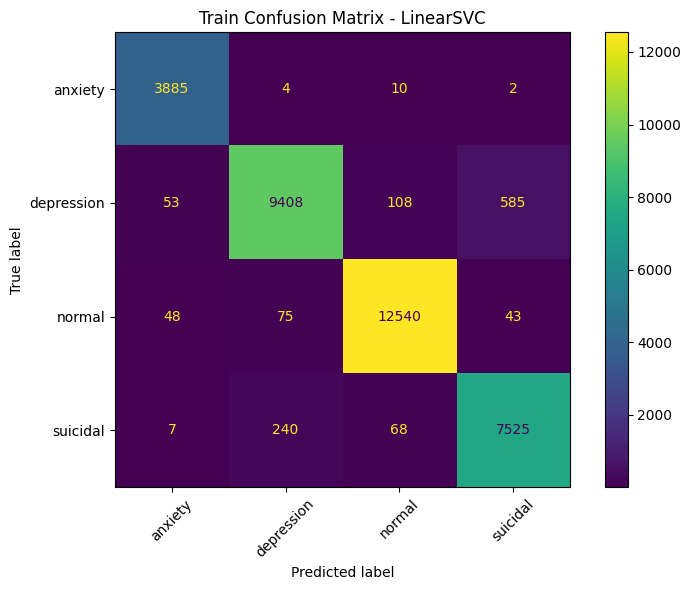

Saved confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/figures/tfidf_linearsvc_tfidf_lexicon_only_v1__train_confusion_matrix.png

Validation Accuracy : 0.7991
Validation Macro F1 : 0.7869
              precision    recall  f1-score   support

     anxiety     0.8145    0.8276    0.8210       557
  depression     0.7444    0.6906    0.7165      1451
      normal     0.9020    0.9443    0.9226      1812
    suicidal     0.6841    0.6908    0.6874      1119

    accuracy                         0.7991      4939
   macro avg     0.7862    0.7883    0.7869      4939
weighted avg     0.7964    0.7991    0.7973      4939

Saved report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/reports/tfidf_linearsvc_tfidf_lexicon_only_v1__validation_report.txt


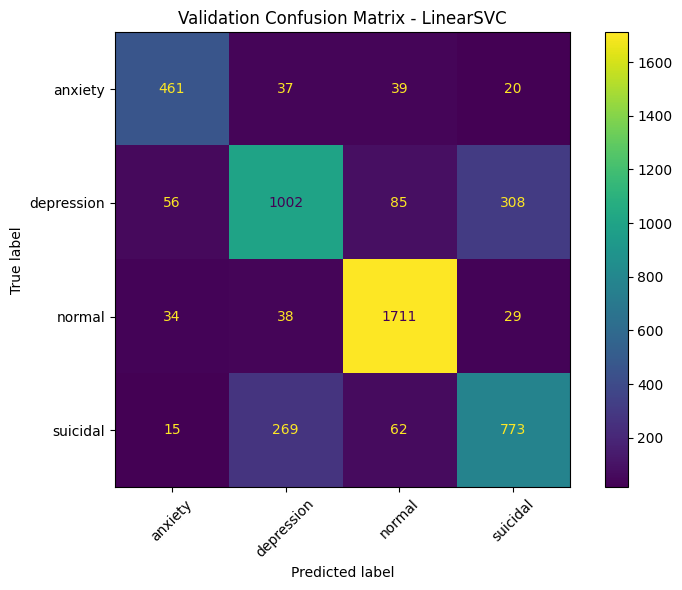

Saved confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/figures/tfidf_linearsvc_tfidf_lexicon_only_v1__validation_confusion_matrix.png

Train-Val Macro F1 Gap: 0.1775667437447105


In [ ]:
def evaluate_split(split_name, y_true, y_pred, labels, report_dir):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print("\n==================================================")
    print(f"{split_name} Accuracy : {acc:.4f}")
    print(f"{split_name} Macro F1 : {macro_f1:.4f}")
    print("==================================================")

    report = classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )

    print(report)

    report_path = os.path.join(
        report_dir,
        f"{EXPERIMENT_NAME}__{split_name.lower()}_report.txt"
    )

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"{split_name.upper()} REPORT - {EXPERIMENT_NAME}\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"Macro F1: {macro_f1:.4f}\n\n")
        f.write(report)

    print("Saved report:", report_path)

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(f"{split_name} Confusion Matrix - LinearSVC")
    plt.tight_layout()

    fig_path = os.path.join(
        FIGURE_DIR,
        f"{EXPERIMENT_NAME}__{split_name.lower()}_confusion_matrix.png"
    )

    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved confusion matrix:", fig_path)

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "report_path": report_path,
        "confusion_matrix_path": fig_path
    }


preds_train = model.predict(X_train_fe)
preds_val = model.predict(X_val_fe)

train_metrics = evaluate_split(
    split_name="Train",
    y_true=y_train,
    y_pred=preds_train,
    labels=class_names,
    report_dir=REPORT_DIR
)

val_metrics = evaluate_split(
    split_name="Validation",
    y_true=y_val,
    y_pred=preds_val,
    labels=class_names,
    report_dir=REPORT_DIR
)

print("\nTrain-Val Macro F1 Gap:", train_metrics["macro_f1"] - val_metrics["macro_f1"])


Test Accuracy : 0.7931
Test Macro F1 : 0.7806
              precision    recall  f1-score   support

     anxiety     0.8072    0.8268    0.8169      1114
  depression     0.7316    0.6824    0.7062      2900
      normal     0.9048    0.9410    0.9225      3625
    suicidal     0.6733    0.6802    0.6768      2236

    accuracy                         0.7931      9875
   macro avg     0.7792    0.7826    0.7806      9875
weighted avg     0.7905    0.7931    0.7914      9875

Saved report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/reports/tfidf_linearsvc_tfidf_lexicon_only_v1__test_report.txt


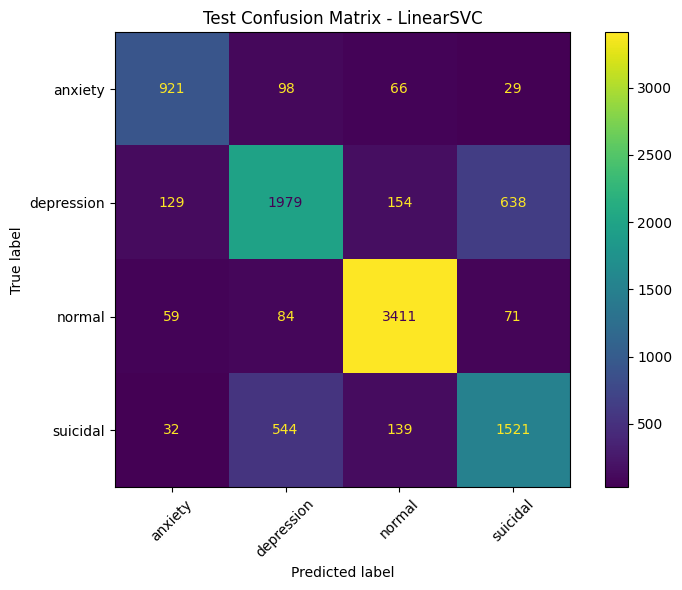

Saved confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/figures/tfidf_linearsvc_tfidf_lexicon_only_v1__test_confusion_matrix.png
Saved summary: /content/drive/MyDrive/CS114/TeamModel/experiments/linearsvc_tfidf_lexicon_summary.csv


,experiment_name,model,feature_mode,svm_c,class_weight,dual,feature_k,word_ngram_range,char_analyzer,char_ngram_range,train_macro_f1,val_macro_f1,test_macro_f1,train_accuracy,val_accuracy,test_accuracy,gap_train_val
0,tfidf_linearsvc_tfidf_lexicon_only_v1,LinearSVC,tfidf_plus_depression_suicide_lexicon_only,0.8,balanced,False,35000,"(1, 3)",char_wb,"(3, 5)",0.96445,0.786884,0.780568,0.964076,0.79915,0.793114,0.177567


In [ ]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    preds_test = model.predict(X_test_fe)

    test_metrics = evaluate_split(
        split_name="Test",
        y_true=y_test,
        y_pred=preds_test,
        labels=class_names,
        report_dir=REPORT_DIR
    )

    summary_row = {
        "experiment_name": EXPERIMENT_NAME,
        "model": "LinearSVC",
        "feature_mode": "tfidf_plus_depression_suicide_lexicon_only",
        "svm_c": SVM_C,
        "class_weight": "balanced",
        "dual": False,
        "feature_k": FEATURE_K,
        "word_ngram_range": str(WORD_NGRAM_RANGE),
        "char_analyzer": CHAR_ANALYZER,
        "char_ngram_range": str(CHAR_NGRAM_RANGE),
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "gap_train_val": train_metrics["macro_f1"] - val_metrics["macro_f1"],
    }

    SUMMARY_PATH = os.path.join(
        BASE_DIR,
        "experiments",
        "linearsvc_tfidf_lexicon_summary.csv"
    )

    if os.path.exists(SUMMARY_PATH):
        old_summary = pd.read_csv(SUMMARY_PATH)
        new_summary = pd.concat(
            [old_summary, pd.DataFrame([summary_row])],
            ignore_index=True
        )
    else:
        new_summary = pd.DataFrame([summary_row])

    new_summary.to_csv(
        SUMMARY_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved summary:", SUMMARY_PATH)
    display(new_summary.sort_values("val_macro_f1", ascending=False).head(20))

In [ ]:
INFERENCE_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_report.json"
)

INFERENCE_SUMMARY_CSV_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_summary.csv"
)


def predict_full_pipeline_with_timing(df_input):
    start_time = time.perf_counter()

    X_fe = transform_with_feature_pipeline(
        df_input,
        feature_pipeline
    )

    preds = model.predict(X_fe)

    total_time = time.perf_counter() - start_time

    return preds, total_time


warmup_n = min(10, len(test_enriched))

_ = predict_full_pipeline_with_timing(
    test_enriched.iloc[:warmup_n].copy()
)

print(f"Warm-up completed on {warmup_n} samples.")


preds_test_timed, test_inference_time = predict_full_pipeline_with_timing(
    test_enriched.copy()
)

n_test_samples = len(test_enriched)
avg_time_per_sample = test_inference_time / n_test_samples
samples_per_second = n_test_samples / test_inference_time if test_inference_time > 0 else None

timed_acc = accuracy_score(y_test, preds_test_timed)
timed_macro_f1 = f1_score(y_test, preds_test_timed, average="macro")

inference_report = {
    "experiment_name": EXPERIMENT_NAME,
    "model": "LinearSVC",
    "n_samples": int(n_test_samples),
    "total_inference_time_seconds": float(test_inference_time),
    "avg_inference_time_per_sample_seconds": float(avg_time_per_sample),
    "avg_inference_time_per_sample_ms": float(avg_time_per_sample * 1000),
    "samples_per_second": None if samples_per_second is None else float(samples_per_second),
    "accuracy": float(timed_acc),
    "macro_f1": float(timed_macro_f1),
    "timing_scope": "full raw-text pipeline: TF-IDF transform + chi-square transform + lexicon scaling + LinearSVC predict",
}

with open(INFERENCE_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_report, f, ensure_ascii=False, indent=2)

pd.DataFrame([inference_report]).to_csv(
    INFERENCE_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(json.dumps(inference_report, indent=2, ensure_ascii=False))
print("Saved inference report:", INFERENCE_REPORT_PATH)
print("Saved inference summary:", INFERENCE_SUMMARY_CSV_PATH)

Warm-up completed on 10 samples.
{
  "experiment_name": "tfidf_linearsvc_tfidf_lexicon_only_v1",
  "model": "LinearSVC",
  "n_samples": 9875,
  "total_inference_time_seconds": 7.833140575000016,
  "avg_inference_time_per_sample_seconds": 0.0007932294253164573,
  "avg_inference_time_per_sample_ms": 0.7932294253164573,
  "samples_per_second": 1260.669319725566,
  "accuracy": 0.7931139240506329,
  "macro_f1": 0.7805684548464082,
  "timing_scope": "full raw-text pipeline: TF-IDF transform + chi-square transform + lexicon scaling + LinearSVC predict"
}
Saved inference report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/reports/tfidf_linearsvc_tfidf_lexicon_only_v1__inference_time_report.json
Saved inference summary: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_linearsvc_tfidf_lexicon_only_v1/reports/tfidf_linearsvc_tfidf_lexicon_only_v1__inference_time_summary.csv


In [ ]:
PACKAGE_DIR = "/content/drive/MyDrive/CS114/TeamModel/demo_model"
os.makedirs(PACKAGE_DIR, exist_ok=True)

PACKAGE_PATH = os.path.join(
    PACKAGE_DIR,
    "tfidf_linearsvc_tfidf_lexicon_only_demo_bundle.joblib"
)

required_vars = [
    "feature_pipeline",
    "model",
    "class_names",
    "EXPERIMENT_NAME",
    "config"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Thiếu các biến cần thiết để đóng gói model: {missing_vars}. "
        "Hãy chạy xong phần train/load LinearSVC trước."
    )

demo_bundle = {
    "experiment_name": EXPERIMENT_NAME,
    "feature_pipeline": feature_pipeline,
    "model": model,
    "class_names": np.array(class_names),
    "config": config,
    "model_type": "LinearSVC",
    "note": "LinearSVC does not output calibrated probabilities. Use predict() or decision_function() for raw margins.",
}

joblib.dump(demo_bundle, PACKAGE_PATH)

print("Saved demo bundle:", PACKAGE_PATH)
print("Bundle keys:", demo_bundle.keys())

Saved demo bundle: /content/drive/MyDrive/CS114/TeamModel/demo_model/tfidf_linearsvc_tfidf_lexicon_only_demo_bundle.joblib
Bundle keys: dict_keys(['experiment_name', 'feature_pipeline', 'model', 'class_names', 'config', 'model_type', 'note'])
